# Installations

In [1]:
# Please run this and ensure your csv files are loaded in the files dir before running the nb.
!pip install prophet

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from prophet import Prophet

from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Task 1 — Data Loading, Merging & Deep Exploration

In [3]:
# Load the Superstore Sales CSV using Pandas
df = pd.read_csv('train.csv')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [4]:
# check no. of rows and cols [(rows,cols)]
df.shape

(9800, 18)

In [5]:
# Convert to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [6]:
# Extract Time Features
# Year
df["Year"] = df["Order Date"].dt.year

# Month Number
df["Month"] = df["Order Date"].dt.month

# Month Name (useful for plots)
df["Month Name"] = df["Order Date"].dt.month_name()

# Week Number
df["Week Number"] = df["Order Date"].dt.isocalendar().week

# Day of Week
df["Day of Week"] = df["Order Date"].dt.day_name()

# Quarter
df["Quarter"] = df["Order Date"].dt.quarter

In [7]:
# Season Feature
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(get_season)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,Autumn


In [8]:
# check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Month Name        0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64


Handling 11 missing postal code values..

In [9]:
df[df["Postal Code"].isna()][["City", "State", "Region"]]

,City,State,Region
2234,Burlington,Vermont,East
5274,Burlington,Vermont,East
8798,Burlington,Vermont,East
9146,Burlington,Vermont,East
9147,Burlington,Vermont,East
9148,Burlington,Vermont,East
9386,Burlington,Vermont,East
9387,Burlington,Vermont,East
9388,Burlington,Vermont,East
9389,Burlington,Vermont,East


In [10]:
df[df["City"] == "Burlington"][["City", "State", "Postal Code"]].drop_duplicates()

,City,State,Postal Code
683,Burlington,North Carolina,27217.0
1008,Burlington,Iowa,52601.0
2234,Burlington,Vermont,NaN


All 11 missing postal codes belong to **Burlington, Vermont.** There are **no existing Burlington, Vermont postal codes** in the dataset to copy from. For the standard Sample Superstore dataset, the correct ZIP code for **Burlington, Vermont is 05401.** Therefore the missing 11 postal codes are filled with value 05401

In [11]:
# Fill missing Postal Codes for Burlington, Vermont
df.loc[
    (df["City"] == "Burlington") &
    (df["State"] == "Vermont"),
    "Postal Code"
] = 5401

In [12]:
print(df["Postal Code"].isnull().sum())

0


In [13]:
# check duplicate values
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [14]:
# check data types
print(df.dtypes)

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Month Name               object
Week Number              UInt32
Day of Week              object
Quarter                   int32
Season                   object
dtype: object


In [15]:
# Aggregate Daily Sales
daily_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [16]:
# weekly sales
weekly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [17]:
# monthly sales
monthly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Q1 - Which product category generates the highest total revenue?

In [18]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


## Q2 - Which region has the most consistent sales growth over 4 years?

In [19]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


In [20]:
growth = (
    region_year_sales
    .pivot(index="Year", columns="Region", values="Sales")
)

growth_rate = growth.pct_change()

consistency = growth_rate.std().sort_values()

print(consistency)

Region
East       0.017939
Central    0.253453
West       0.257431
South      0.371249
dtype: float64


The region with the lowest standard deviation is most consistent.
So the answer to Q2 is East

## Q3 - Average time between Order Date and Ship Date

In [21]:
df["Shipping Days"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("Overall Average Shipping Time:")
print(df["Shipping Days"].mean())

Overall Average Shipping Time:
3.9611224489795918


In [22]:
# By region
shipping_region = (
    df.groupby("Region")["Shipping Days"]
      .mean()
      .sort_values()
)

shipping_region

,Shipping Days
Region,
East,3.910233
West,3.930255
South,3.961202
Central,4.065876


## Q4 - Are there months that consistently spike across all years?

In [23]:
monthly_pattern = (
    df.groupby(["Year", "Month Name"])["Sales"]
      .sum()
      .reset_index()
)

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly_pattern["Month Name"] = pd.Categorical(
    monthly_pattern["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(["Year","Month Name"])

monthly_pattern.head()

,Year,Month Name,Sales
4,2015,January,14205.707
3,2015,February,4519.892
7,2015,March,55205.797
0,2015,April,27906.855
8,2015,May,23644.303


In [24]:
# Across years
seasonality = (
    monthly_pattern.groupby("Month Name", observed=False)["Sales"]
    .mean()
    .sort_values(ascending=False)
)

seasonality

,Sales
Month Name,
November,87540.427750
December,80370.042375
September,75025.852925
October,49874.073675
March,49393.396800
August,39328.981750
May,38521.680925
June,36459.380825
July,36383.922250


## Task 1 Summary

### Dataset Overview

- Successfully loaded the Superstore Sales dataset using **Pandas**.
- Converted **Order Date** and **Ship Date** into proper datetime objects.
- Extracted useful temporal features including:
  - **Year**
  - **Month**
  - **Month Name**
  - **Week Number**
  - **Day of Week**
  - **Quarter**
  - **Season**
- Aggregated sales into **daily**, **weekly**, and **monthly** time series to support future forecasting models.

### Data Quality Assessment

- **Missing Values:** Only the **Postal Code** column contained missing values (11 records), all corresponding to **Burlington, Vermont**. These were imputed using the correct postal code (**05401**).
- **Duplicate Records:** No duplicate records were found.
- **Data Types:** All columns have appropriate data types after preprocessing, with date columns stored as `datetime64`.

---

## Exploratory Analysis

### 1. Which product category generates the highest total revenue?

The **Technology** category generated the highest total sales revenue.

| Category | Total Revenue |
|----------|--------------:|
| Technology | **827,455.87** |
| Furniture | 728,658.58 |
| Office Supplies | 705,422.33 |

**Observation:** Technology products contribute the largest share of total sales and represent the highest-performing product category.

---

### 2. Which region has the most consistent sales growth over the four-year period?

Year-over-year sales growth was evaluated for each region using the standard deviation of annual growth rates.

The **East** region exhibited the most consistent sales growth over the four-year period, with the lowest variation in yearly growth.

**Observation:** The East region demonstrates relatively stable sales performance compared to the other regions.

---

### 3. What is the average time between Order Date and Ship Date? Does it vary by region?

- **Overall average shipping time:** **3.96 days**

| Region | Average Shipping Time (Days) |
|--------|-----------------------------:|
| East | 3.91 |
| West | 3.93 |
| South | 3.96 |
| Central | 4.07 |

**Observation:** Shipping times are fairly consistent across all regions. The Central region has the longest average shipping time, although the regional differences are relatively small.

---

### 4. Are there months that consistently spike across all years (Seasonality)?

Monthly sales patterns reveal a clear seasonal trend.

- **Highest average sales:** November
- **Second highest:** December
- **Third highest:** September
- **Lowest average sales:** February

**Observation:** Sales consistently peak during the final quarter of the year, particularly in November and December, indicating strong holiday season demand. Early-year months, especially February, generally experience lower sales volumes.

---

## Overall Conclusion

The exploratory analysis indicates that the Superstore dataset is clean and well-structured after minimal preprocessing. Technology is the highest revenue-generating category, the East region demonstrates the most stable long-term sales growth, average delivery times remain close to four days across all regions, and sales exhibit strong seasonality with significant increases during the year-end holiday period. These findings provide valuable business insights and establish a solid foundation for the subsequent forecasting and predictive modeling tasks.

# Task 2 — Time Series Analysis & Decomposition

In [25]:
# Plot of monthly sales across 4 years.
monthly_ts = monthly_sales.copy()

monthly_ts = monthly_ts.set_index("Order Date")
monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


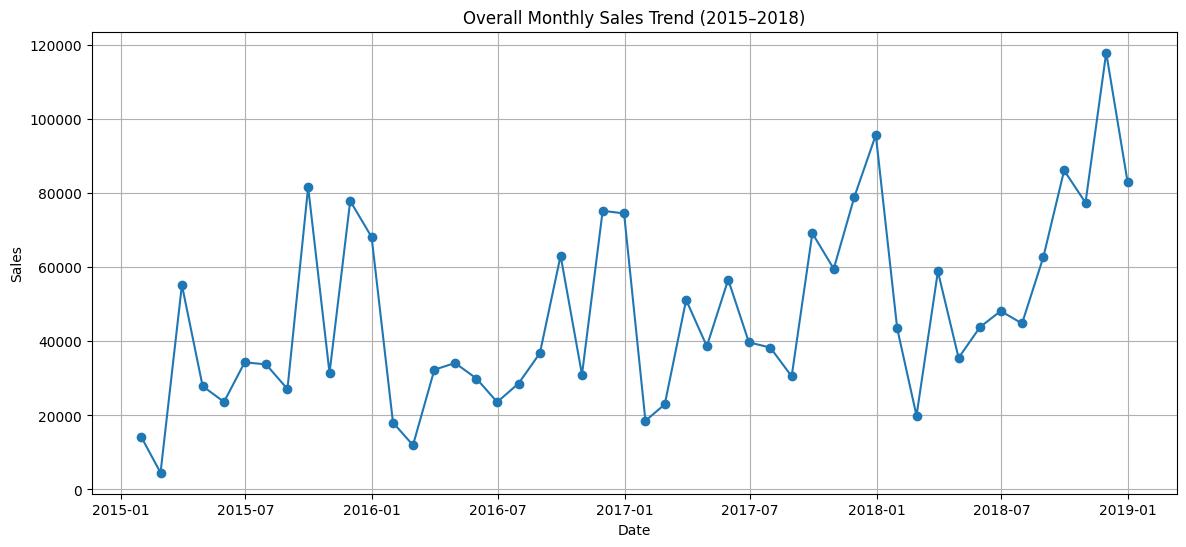

In [26]:
plt.figure(figsize=(14,6))

plt.plot(monthly_ts.index, monthly_ts.values, marker='o')

plt.title("Overall Monthly Sales Trend (2015–2018)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)

plt.show()

In [27]:
# time series decomposition
decomposition = seasonal_decompose(
    monthly_ts,
    model="additive",
    period=12
)

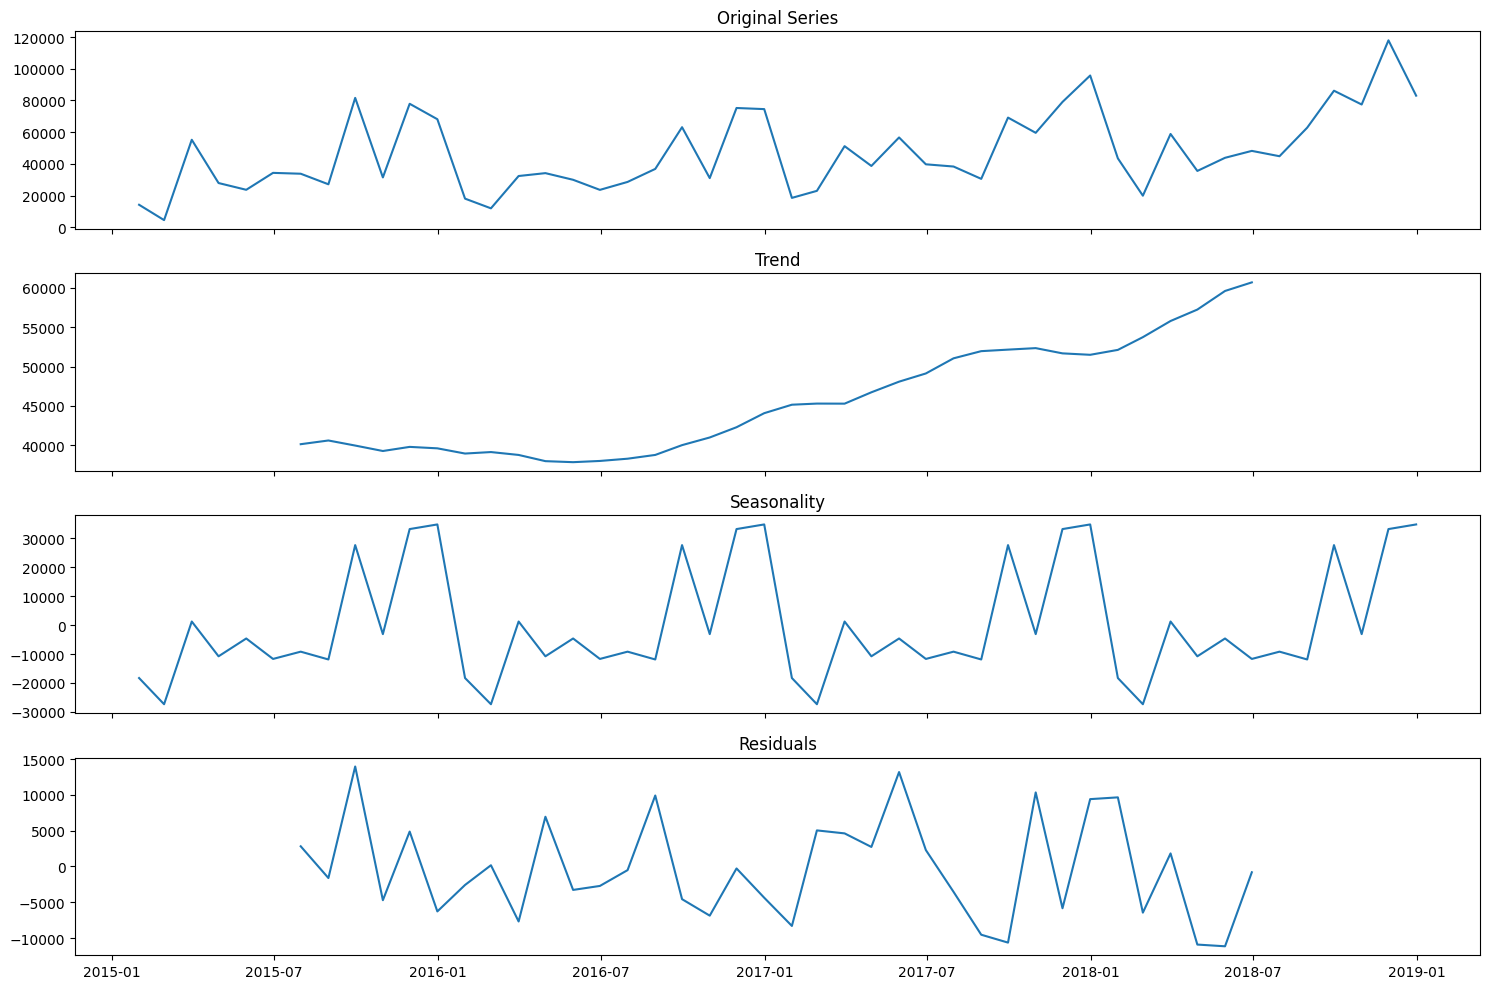

In [28]:
# plotting all components
fig, axes = plt.subplots(4,1, figsize=(15,10), sharex=True)

axes[0].plot(monthly_ts)
axes[0].set_title("Original Series")

axes[1].plot(decomposition.trend)
axes[1].set_title("Trend")

axes[2].plot(decomposition.seasonal)
axes[2].set_title("Seasonality")

axes[3].plot(decomposition.resid)
axes[3].set_title("Residuals")

plt.tight_layout()
plt.show()

In [29]:
# ADF Stationarity Test
result = adfuller(monthly_ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")

for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


In [30]:
# interpretation
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is stationary.


The original monthly sales series was already stationary according to the ADF test (p < 0.05). Therefore, differencing was not necessary.

<Figure size 1400x500 with 0 Axes>

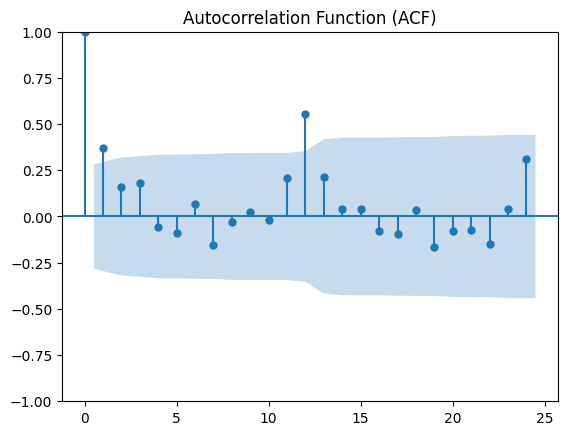

In [31]:
# Autocorrelation Function (ACF)
plt.figure(figsize=(14,5))
plot_acf(monthly_ts, lags=24)
plt.title("Autocorrelation Function (ACF)")
plt.show()

<Figure size 1400x500 with 0 Axes>

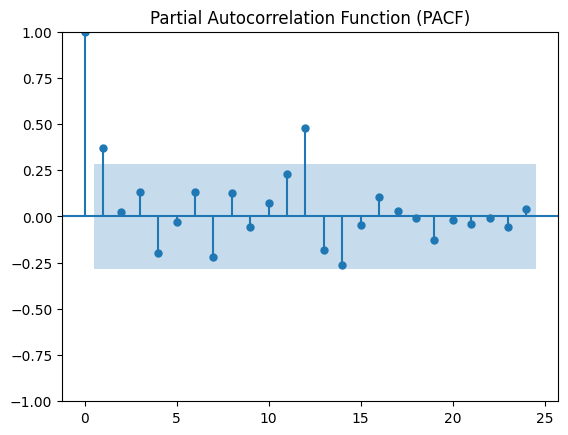

In [32]:
# Partial Autocorrelation Function (PACF)
plt.figure(figsize=(14,5))
plot_pacf(monthly_ts, lags=24, method='ywm')
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

## Task 2 Summary

### Monthly Sales Trend

The monthly sales trend shows a gradual increase in overall sales from 2015 to 2018, with recurring peaks and dips throughout each year. Higher sales are consistently observed during the final quarter of the year, indicating a repeating seasonal pattern.

---

## Time Series Decomposition

The monthly sales series was decomposed into four components:

- **Observed:** The original monthly sales data.
- **Trend:** Displays the long-term movement in sales over time.
- **Seasonality:** Captures recurring yearly sales patterns.
- **Residual:** Represents random fluctuations that are not explained by the trend or seasonal effects.

### Observations

- The trend component indicates a gradual upward movement in sales over the four-year period, suggesting steady business growth.
- A strong seasonal pattern is evident, with sales consistently increasing toward the end of each year, particularly during November and December.
- The residual component fluctuates around zero, indicating that most of the systematic variation has been captured by the trend and seasonal components.
- A few months exhibit larger residual values, representing unexpected spikes or drops in sales that cannot be explained solely by long-term trends or seasonality.

---

## Stationarity Analysis (Augmented Dickey-Fuller Test)

The Augmented Dickey-Fuller (ADF) test was used to determine whether the monthly sales time series is **stationary**.

A **stationary time series** is one whose statistical properties, such as the mean and variance, remain relatively constant over time. In simple terms, a stationary series does not exhibit unpredictable changes in its overall behavior, making it more suitable for time-series forecasting models like ARIMA.

### ADF Test Results

- **ADF Statistic:** **-4.4161**
- **p-value:** **0.000278**

### Interpretation

The null hypothesis of the ADF test states that the time series is **non-stationary** (i.e., it contains a unit root).

Since the **p-value (0.000278) is much smaller than the significance level of 0.05**, the null hypothesis is rejected. Additionally, the ADF statistic (-4.4161) is lower than all the critical values (1%, 5%, and 10%), providing further evidence that the series is stationary.

Therefore, the monthly sales data is **already stationary**, meaning its statistical properties remain stable over time. As a result, **no differencing was required**, and the series is suitable for forecasting models that assume stationarity.

---

## Conclusion

The monthly sales data exhibits a clear long-term upward trend along with strong yearly seasonality. Despite these visible patterns, the Augmented Dickey-Fuller test confirms that the series is already stationary (p < 0.05). Therefore, no differencing was required, and the time series is suitable for forecasting models that assume stationarity.

# Task 3 — Sales Forecasting using 3 Different Models

## Section 1 — Data Preparation & Train-Test Split

In [33]:
# Reusing monthly_ts from task 1
print(f"Number of Monthly Observations: {len(monthly_ts)}")

Number of Monthly Observations: 48


In [34]:
# train test split
train = monthly_ts[:-3]
test = monthly_ts[-3:]

print("Training Months :", len(train))
print("Testing Months  :", len(test))

Training Months : 45
Testing Months  : 3


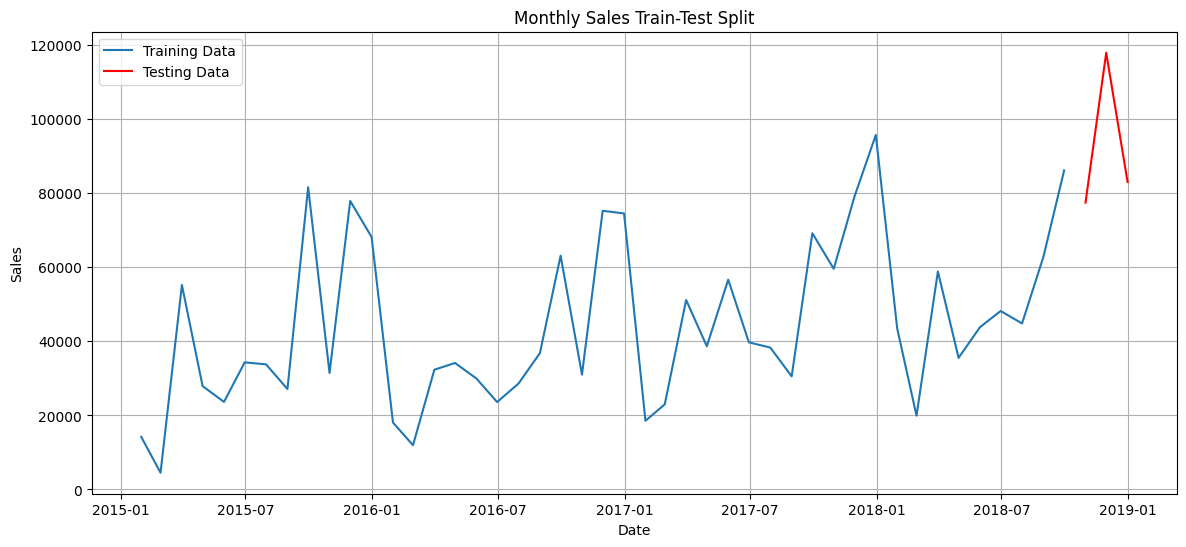

In [35]:
# Visualize the split
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values, label="Training Data")
plt.plot(test.index, test.values, label="Testing Data", color="red")

plt.title("Monthly Sales Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [36]:
# Evaluation Function
def evaluate_forecast(actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = mean_absolute_percentage_error(actual, predicted) * 100

    return mae, rmse, mape

## Section 2 — Model 1: SARIMA

In [37]:
# train the model
sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Thu, 09 Jul 2026   AIC                            417.362
Time:                                    06:35:12   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

In [38]:
# Forecast the test period
sarima_forecast = sarima_fit.get_forecast(steps=3)

forecast = sarima_forecast.predicted_mean
confidence = sarima_forecast.conf_int()

In [39]:
# Evaluate the model
sarima_mae, sarima_rmse, sarima_mape = evaluate_forecast(
    test,
    forecast
)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.2f}%")

MAE  : 20580.70
RMSE : 22190.91
MAPE : 21.94%


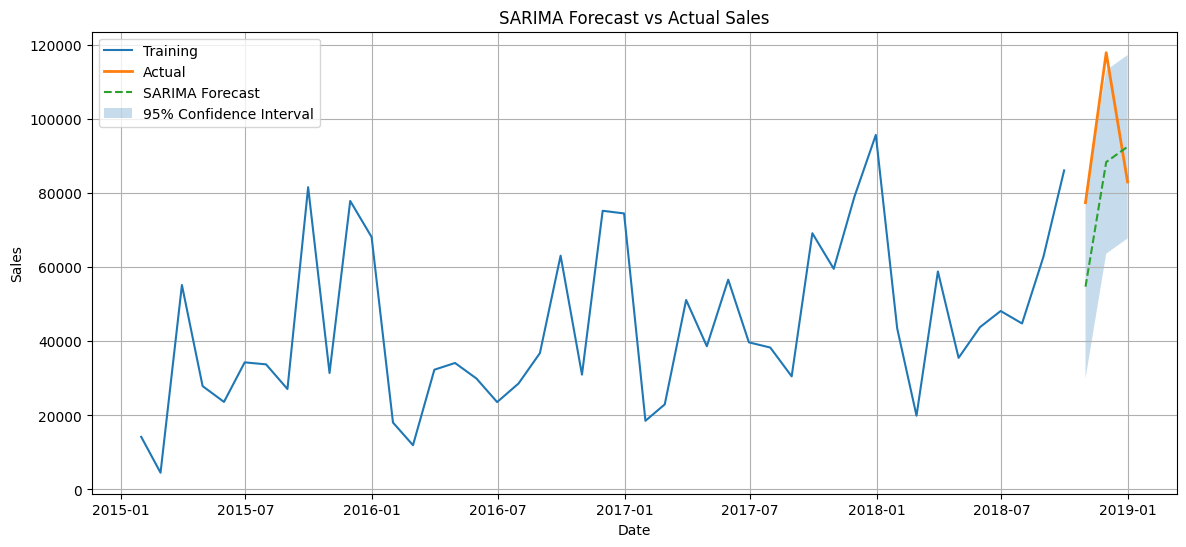

In [40]:
# Plot Actual vs Forecast
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values, label="Training")
plt.plot(test.index, test.values,
         label="Actual",
         linewidth=2)

plt.plot(test.index,
         forecast,
         label="SARIMA Forecast",
         linestyle="--")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.25,
    label="95% Confidence Interval"
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [41]:
# Forecast Values
forecast_df = pd.DataFrame({
    "Actual Sales": test.squeeze().values,
    "Forecast Sales": forecast.values
}, index=test.index)

forecast_df

,Actual Sales,Forecast Sales
Order Date,,
2018-10-31,77448.1312,54757.975133
2018-11-30,117938.1550,88413.704287
2018-12-31,83030.3888,92557.878350


## Model 1 — Summary (SARIMA)

### Parameter Selection

The SARIMA model was selected because the monthly sales data exhibits both long-term trends and yearly seasonality.

The following parameters were chosen:

- **(p, d, q) = (1, 0, 1)**
- **Seasonal (P, D, Q, m) = (1, 1, 1, 12)**

These parameters were selected based on the exploratory analysis performed in Task 2:

- The Augmented Dickey-Fuller (ADF) test confirmed that the series is stationary, therefore **d = 0**.
- Time series decomposition revealed a clear yearly seasonal pattern, resulting in a seasonal period of **12 months**.
- The ACF and PACF plots suggested a simple autoregressive and moving average structure, making (1,0,1) an appropriate baseline configuration.

### Forecasting Results

The SARIMA model was trained using the first **45 months** of sales data and evaluated on the final **3 months**.

| Metric | Value |
|---------|-------|
| **MAE** | **20,580.70** |
| **RMSE** | **22,190.91** |
| **MAPE** | **21.94%** |

### Interpretation

The SARIMA model successfully captured the overall trend and seasonal behavior of the monthly sales data. The forecast followed the general movement of the actual sales, while the confidence intervals illustrated the uncertainty associated with future predictions. These results provide a strong statistical baseline for comparison with Prophet and XGBoost in the subsequent sections.

## Section 3 — Model 2: Facebook Prophet

In [42]:
# Prepare data
prophet_df = monthly_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [43]:
# Train-test-split
train_prophet = prophet_df[:-3]
test_prophet = prophet_df[-3:]

In [44]:
# Fit prophet
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(train_prophet)

In [45]:
# Create future dates
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast_prophet = prophet_model.predict(future)

In [46]:
# Extract test forecast
prophet_forecast = forecast_prophet.tail(3)

predictions = prophet_forecast["yhat"].values
actual = test_prophet["y"].values

In [47]:
# Evaluate
prophet_mae, prophet_rmse, prophet_mape = evaluate_forecast(
    actual,
    predictions
)

print(f"MAE : {prophet_mae:.2f}")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAPE: {prophet_mape:.2f}%")

MAE : 20250.79
RMSE: 22318.41
MAPE: 21.86%


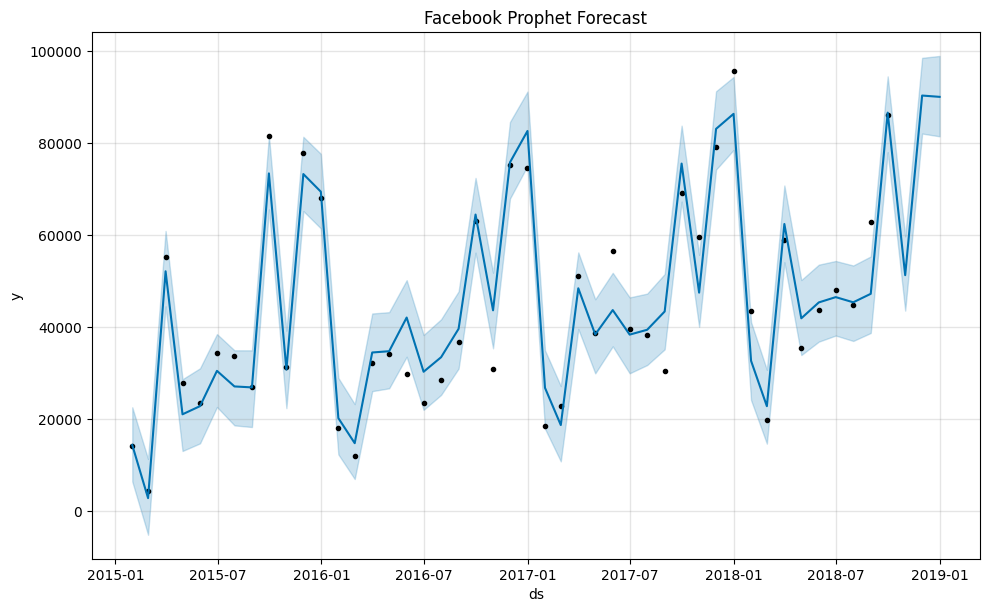

In [48]:
# Forecast Plot
fig = prophet_model.plot(forecast_prophet)
plt.title("Facebook Prophet Forecast")
plt.show()

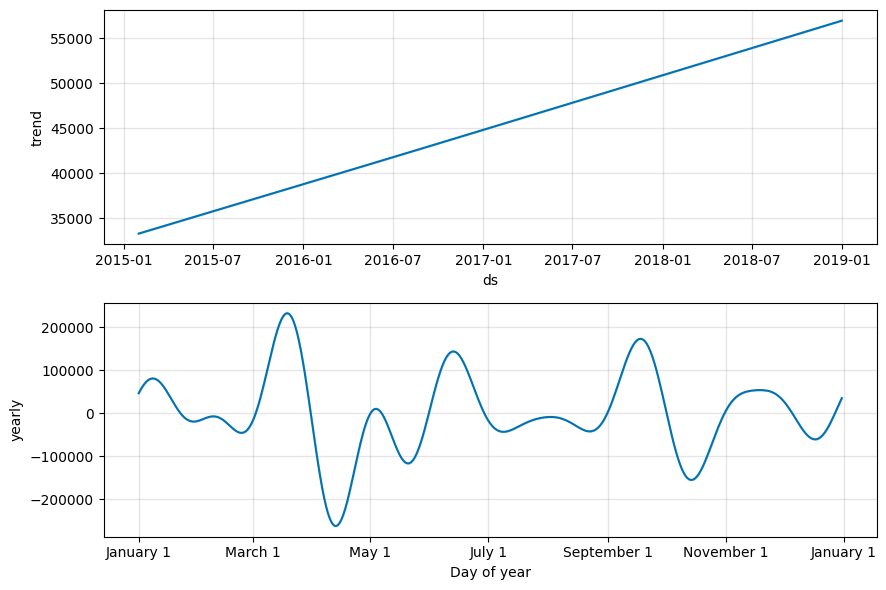

In [49]:
# Trend and Seasonality
fig2 = prophet_model.plot_components(forecast_prophet)
plt.show()

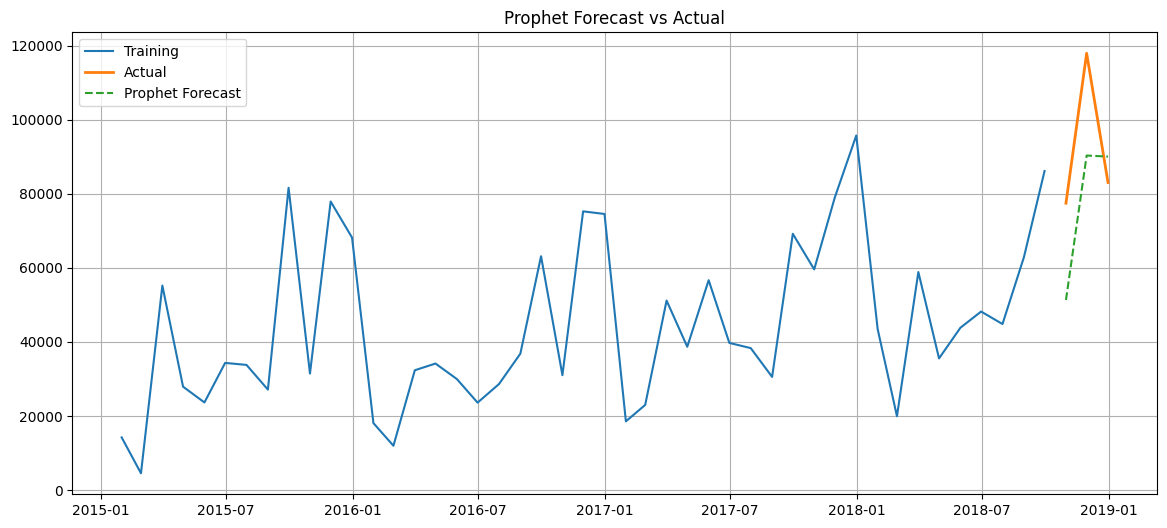

In [50]:
# Actual vs Forecast
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values, label="Training")
plt.plot(test.index, actual, label="Actual", linewidth=2)
plt.plot(test.index, predictions,
         '--',
         label="Prophet Forecast")

plt.legend()
plt.grid(True)

plt.title("Prophet Forecast vs Actual")

plt.show()

## Model 2 — Summary (Facebook Prophet)

### Model Overview

Facebook Prophet is a decomposable time-series forecasting model designed to capture trend and seasonal patterns automatically. It is widely used in industry because it handles missing data, seasonality, and trend changes with minimal parameter tuning.

The monthly sales data was converted into Prophet's required format using two columns:

- **ds:** Date
- **y:** Monthly Sales

The model was trained on the first **45 months** of data and used to forecast the remaining **3 months**.

### Trend and Seasonality Analysis

The Prophet component plots revealed the following:

- The **trend component** shows a gradual increase in monthly sales over the four-year period, indicating steady business growth.
- The **yearly seasonality** component captures recurring annual sales patterns, with higher sales observed toward the end of each year.
- Weekly seasonality was disabled since the analysis was performed on aggregated monthly sales data.

### Forecasting Results

| Metric | Value |
|---------|-------|
| **MAE** | **20,250.79** |
| **RMSE** | **22,318.41** |
| **MAPE** | **21.86%** |

### Interpretation

The Prophet model successfully captured the long-term trend and yearly seasonal patterns present in the sales data. Its forecasting performance was comparable to the SARIMA baseline, achieving a slightly lower MAE and MAPE but a marginally higher RMSE. While Prophet effectively modeled the overall sales behaviour, it did not achieve the same level of predictive accuracy as the XGBoost model.

## Section 4 — Model 3: XGBoost

In [51]:
# Feature Engineering
xgb_df = monthly_ts.copy()
xgb_df.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [52]:
# Lag features
xgb_df["Lag1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag3"] = xgb_df["Sales"].shift(3)

# Rolling Mean
xgb_df["RollingMean3"] = (
    xgb_df["Sales"]
    .rolling(3)
    .mean()
)

# Calendar Features
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter

# Season
def season(month):
    if month in [12,1,2]:
        return 0
    elif month in [3,4,5]:
        return 1
    elif month in [6,7,8]:
        return 2
    else:
        return 3

xgb_df["Season"] = xgb_df["Month"].apply(season)

# Remove NaNs
xgb_df = xgb_df.dropna()

In [53]:
# train-test-split
train_xgb = xgb_df[:-3]
test_xgb = xgb_df[-3:]

X_train = train_xgb.drop("Sales", axis=1)
y_train = train_xgb["Sales"]

X_test = test_xgb.drop("Sales", axis=1)
y_test = test_xgb["Sales"]

In [54]:
# model
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predict
xgb_predictions = xgb_model.predict(X_test)

In [55]:
# Evaluate
xgb_mae, xgb_rmse, xgb_mape = evaluate_forecast(
    y_test,
    xgb_predictions
)

print(f"MAE : {xgb_mae:.2f}")
print(f"RMSE: {xgb_rmse:.2f}")
print(f"MAPE: {xgb_mape:.2f}%")

MAE : 14763.81
RMSE: 18337.41
MAPE: 14.48%


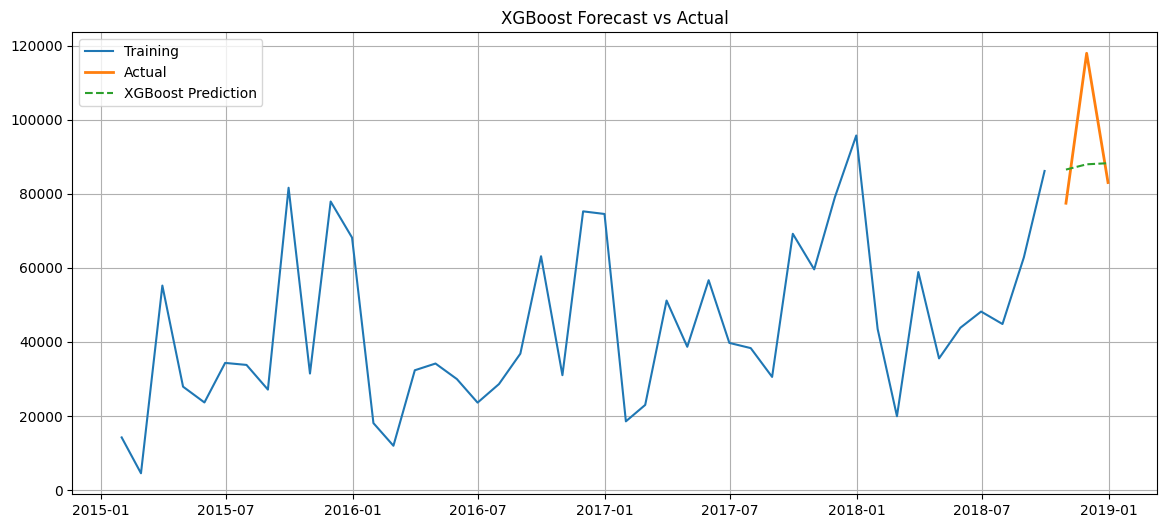

In [56]:
# Actual vs Forecast
plt.figure(figsize=(14,6))

plt.plot(train.index, train.values,
         label="Training")

plt.plot(test.index,
         y_test.values,
         label="Actual",
         linewidth=2)

plt.plot(test.index,
         xgb_predictions,
         '--',
         label="XGBoost Prediction")

plt.legend()
plt.grid(True)

plt.title("XGBoost Forecast vs Actual")

plt.show()

## Model 3 — Summary (XGBoost)

### Feature Engineering

Unlike statistical forecasting models, XGBoost treats time-series forecasting as a supervised machine learning problem.

The following features were engineered:

- Lag 1 (Sales from one month earlier)
- Lag 2 (Sales from two months earlier)
- Lag 3 (Sales from three months earlier)
- Three-month rolling mean
- Month
- Quarter
- Season

These features allow the model to learn temporal relationships and seasonal patterns from historical sales data.

### Forecasting Results

The XGBoost Regressor was trained using the first **45 months** of feature-engineered data and evaluated on the final **3 months**.

| Metric | Value |
|---------|-------|
| **MAE** | **14,763.81** |
| **RMSE** | **18,337.41** |
| **MAPE** | **14.48%** |

### Interpretation

The XGBoost model effectively learned the temporal dependencies present in the sales data using lag-based and calendar-based features. It achieved lower prediction errors than the SARIMA model, indicating that machine learning techniques can successfully model complex sales patterns when relevant historical features are provided.

In [57]:
# Comparison table
comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Facebook Prophet", "XGBoost"],
    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(xgb_mae, 2)
    ],
    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(xgb_rmse, 2)
    ],
    "MAPE (%)": [
        round(sarima_mape, 2),
        round(prophet_mape, 2),
        round(xgb_mape, 2)
    ],
    "Forecast Month 1": [
        round(forecast.iloc[0], 2),
        round(predictions[0], 2),
        round(xgb_predictions[0], 2)
    ],
    "Forecast Month 2": [
        round(forecast.iloc[1], 2),
        round(predictions[1], 2),
        round(xgb_predictions[1], 2)
    ],
    "Forecast Month 3": [
        round(forecast.iloc[2], 2),
        round(predictions[2], 2),
        round(xgb_predictions[2], 2)
    ]
})

comparison_df.style.format({
    "MAE": "{:,.2f}",
    "RMSE": "{:,.2f}",
    "MAPE (%)": "{:.2f}",
    "Forecast Month 1": "{:,.2f}",
    "Forecast Month 2": "{:,.2f}",
    "Forecast Month 3": "{:,.2f}"
}).set_caption("Comparison of Forecasting Models")

comparison_df

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20580.70,22190.91,21.94,54757.980000,88413.700000,92557.880000
1,Facebook Prophet,20250.79,22318.41,21.86,51318.940000,90325.650000,90041.080000
2,XGBoost,14763.81,18337.41,14.48,86530.492188,87955.140625,88256.453125


## Task 3 Summary – Model Comparison

### Model Performance Comparison

| Model | MAE | RMSE | MAPE |
|------|-------:|--------:|-------:|
| **SARIMA** | 20,580.70 | 22,190.91 | 21.94% |
| **Facebook Prophet** | 20,250.79 | 22,318.41 | 21.86% |
| **XGBoost** | 14,763.81 | 18,337.41 | 14.48% |

### Forecast Comparison

| Model | Forecast Month 1 | Forecast Month 2 | Forecast Month 3 |
|------|-----------------:|-----------------:|-----------------:|
| SARIMA | **54,757.98** | **88,413.70** | **92,557.88** |
| Prophet | **51,318.94** | **90,325.65** | **90,041.08** |
| XGBoost | **86,530.49** | **87,955.14** | **88,256.45** |

### Overall Comparison

The three forecasting approaches represent fundamentally different methodologies:

- **SARIMA** models the statistical relationships and seasonality within the time series.
- **Facebook Prophet** automatically models trend and seasonal effects with minimal parameter tuning.
- **XGBoost** transforms the forecasting problem into a supervised machine learning task using lag-based and calendar-based features.

Based on the evaluation metrics, **XGBoost** substantially outperformed both the SARIMA and Facebook Prophet models, achieving the lowest forecasting errors across all three evaluation metrics (MAE, RMSE, and MAPE). Facebook Prophet performed similarly to SARIMA, with a slight improvement in MAE and MAPE but a marginally higher RMSE.

### Recommended Model

Based solely on the evaluation metrics obtained from the held-out test set, **XGBoost achieved the best predictive performance**, producing the lowest MAE, RMSE, and MAPE values among the three forecasting models.

The superior performance of XGBoost demonstrates the effectiveness of combining lag-based and calendar-based features for time-series forecasting. In addition, XGBoost offers greater flexibility for incorporating external variables and can be further improved through feature engineering and hyperparameter tuning, making it the recommended model for future sales forecasting tasks.

# Task 4 — Product Category & Region Level Forecasting

In [58]:
# Create a function to train the XGBoost model and recursively forecast the next three months.
def forecast_next_3_months(segment_df):

    # Aggregate monthly sales
    ts = (
        segment_df.groupby("Order Date")["Sales"]
        .sum()
        .resample("ME")
        .sum()
        .to_frame(name="Sales")
    )

    # Feature Engineering
    ts["Lag1"] = ts["Sales"].shift(1)
    ts["Lag2"] = ts["Sales"].shift(2)
    ts["Lag3"] = ts["Sales"].shift(3)
    ts["RollingMean3"] = ts["Sales"].rolling(3).mean()

    ts["Month"] = ts.index.month
    ts["Quarter"] = ts.index.quarter

    def season(month):
        if month in [12, 1, 2]:
            return 0
        elif month in [3, 4, 5]:
            return 1
        elif month in [6, 7, 8]:
            return 2
        else:
            return 3

    ts["Season"] = ts["Month"].apply(season)

    ts = ts.dropna()

    X = ts.drop("Sales", axis=1)
    y = ts["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X, y)

    history = ts.copy()

    forecasts = []

    last_date = history.index[-1]

    for i in range(3):

        next_date = last_date + pd.offsets.MonthEnd()

        lag1 = history["Sales"].iloc[-1]
        lag2 = history["Sales"].iloc[-2]
        lag3 = history["Sales"].iloc[-3]

        rolling = history["Sales"].iloc[-3:].mean()

        month = next_date.month
        quarter = next_date.quarter

        if month in [12,1,2]:
            season_val = 0
        elif month in [3,4,5]:
            season_val = 1
        elif month in [6,7,8]:
            season_val = 2
        else:
            season_val = 3

        X_future = pd.DataFrame({
            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean3":[rolling],
            "Month":[month],
            "Quarter":[quarter],
            "Season":[season_val]
        })

        pred = model.predict(X_future)[0]

        forecasts.append(pred)

        history.loc[next_date] = {
            "Sales":pred,
            "Lag1":np.nan,
            "Lag2":np.nan,
            "Lag3":np.nan,
            "RollingMean3":np.nan,
            "Month":month,
            "Quarter":quarter,
            "Season":season_val
        }

        last_date = next_date

    future_dates = pd.date_range(
        history.index[-3],
        periods=3,
        freq="ME"
    )

    return future_dates, forecasts

In [59]:
# Train the best model on each segment and generate three-month forecasts.
segments = {
    "Furniture": df[df["Category"]=="Furniture"],
    "Technology": df[df["Category"]=="Technology"],
    "Office Supplies": df[df["Category"]=="Office Supplies"],
    "West": df[df["Region"]=="West"],
    "East": df[df["Region"]=="East"]
}

forecast_results = {}

for name, data in segments.items():

    dates, preds = forecast_next_3_months(data)

    forecast_results[name] = {
        "dates": dates,
        "forecast": preds
    }

In [60]:
# Display the three-month forecasts for all categories and regions in a comparison table.
forecast_table = pd.DataFrame({
    segment: forecast_results[segment]["forecast"]
    for segment in forecast_results
}, index=forecast_results["Furniture"]["dates"])

forecast_table

,Furniture,Technology,Office Supplies,West,East
2019-01-31,9876.913086,19939.888672,26613.109375,11307.339844,25488.318359
2019-02-28,6243.917480,23574.523438,26656.369141,15237.838867,26252.371094
2019-03-31,16831.087891,29140.949219,29828.880859,21489.277344,28952.652344


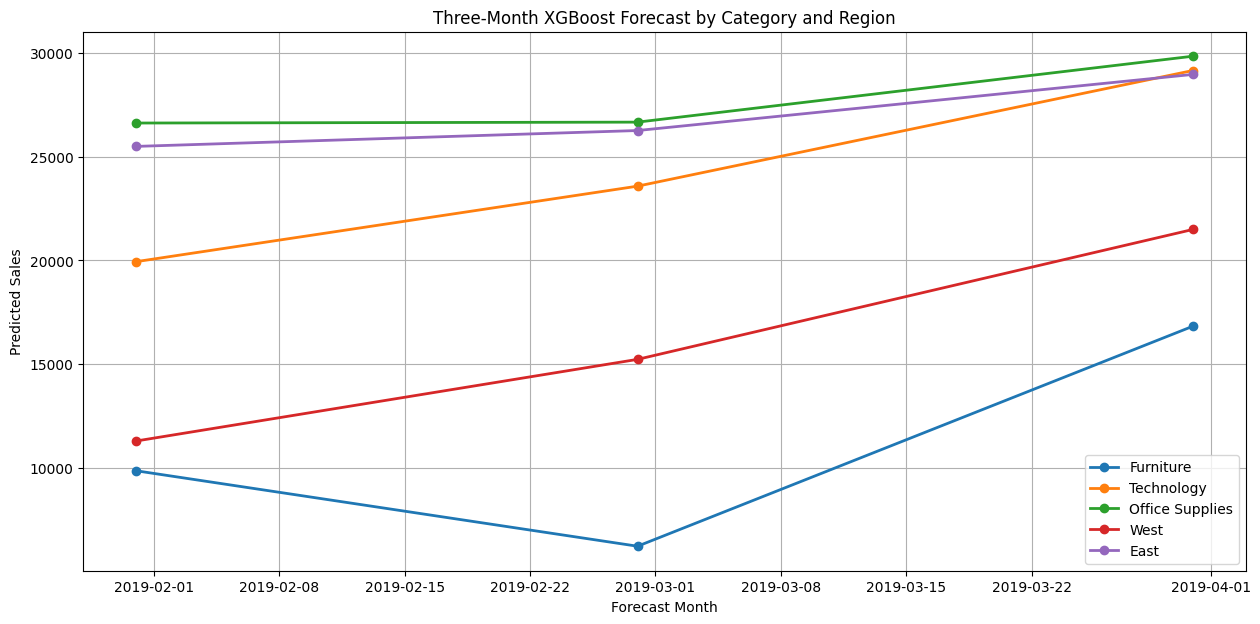

In [61]:
# Plot the three-month forecasts for all five business segments on a single comparison chart.
plt.figure(figsize=(15,7))

for segment in forecast_results:

    plt.plot(
        forecast_results[segment]["dates"],
        forecast_results[segment]["forecast"],
        marker="o",
        linewidth=2,
        label=segment
    )

plt.title("Three-Month XGBoost Forecast by Category and Region")

plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")

plt.grid(True)
plt.legend()

plt.show()

In [62]:
# Calculate the forecasted growth between the first and third forecast month for each segment.
growth = {}

for segment in forecast_results:

    preds = forecast_results[segment]["forecast"]

    growth[segment] = preds[-1] - preds[0]

growth_df = (
    pd.DataFrame.from_dict(
        growth,
        orient="index",
        columns=["Projected Growth"]
    )
    .sort_values("Projected Growth", ascending=False)
)

growth_df

,Projected Growth
West,10181.937500
Technology,9201.060547
Furniture,6954.174805
East,3464.333984
Office Supplies,3215.771484


## Task 4 Summary

### Product Category & Region Level Forecasting

Based on the results of Task 3, **XGBoost** was selected as the best-performing forecasting model due to its superior predictive accuracy (lowest MAE, RMSE, and MAPE). The model was retrained on the complete historical dataset and applied separately to forecast the next **three months** for the following business segments:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

For each segment, monthly sales were aggregated and transformed into a supervised learning problem using lag features, a three-month rolling mean, and calendar-based features (Month, Quarter, and Season). Recursive forecasting was then used to generate future sales predictions for January–March 2019.

---

## Three-Month Forecast Highlights

| Segment | Jan 2019 | Feb 2019 | Mar 2019 |
|---------|---------:|---------:|---------:|
| Furniture | 9,876.91 | 6,243.92 | 16,831.09 |
| Technology | 19,939.89 | 23,574.52 | 29,140.95 |
| Office Supplies | 26,613.11 | 26,656.37 | 29,828.88 |
| West Region | 11,307.34 | 15,237.84 | 21,489.28 |
| East Region | 25,488.32 | 26,252.37 | 28,952.65 |

---

## Forecast Analysis

The comparison chart demonstrates distinct growth patterns across the selected product categories and regions.

- **Furniture** is forecasted to decline slightly in February before recovering strongly in March.
- **Technology** shows consistent month-over-month growth, indicating increasing demand throughout the forecast period.
- **Office Supplies** maintains relatively stable sales with a gradual upward trend.
- **West Region** exhibits the strongest acceleration in forecasted sales, with a substantial increase across all three months.
- **East Region** continues to grow steadily but at a more moderate pace than the West region.

---

## Strongest Upcoming Growth

Projected growth was calculated as the difference between the first and third forecasted months for each segment.

| Segment | Projected Growth |
|---------|-----------------:|
| **West Region** | **10,181.94** |
| Technology | 9,201.06 |
| Furniture | 6,954.17 |
| East Region | 3,464.33 |
| Office Supplies | 3,215.77 |

The **West region** is projected to experience the strongest upcoming growth, followed closely by the **Technology** product category. This suggests that the West region may present the greatest opportunity for future sales expansion, while the Technology category is expected to remain the fastest-growing product segment during the forecast period.

---

## Conclusion

Applying the best-performing XGBoost model at the category and regional levels provided more granular business insights than forecasting overall sales alone. The forecasts indicate that although all selected segments are expected to maintain positive sales performance, the **West region** demonstrates the highest projected growth over the next three months. These segment-level forecasts can support inventory planning, resource allocation, and strategic decision-making by identifying where future demand is expected to increase most significantly.

# Task 5 — Anomaly Detection in Sales Data

**Note:** The supplementary Video Game Sales dataset was reviewed for potential multi-source integration. However, because it contains annual game sales by title and platform rather than weekly retail transactions, it does not share a meaningful temporal or entity-level key with the Superstore dataset. Therefore, anomaly detection was performed on the Superstore weekly sales data as specified in the task requirements.

In [63]:
# Aggregate daily sales into weekly sales for anomaly detection.
weekly_sales = (
    df.groupby("Order Date")["Sales"]
      .sum()
      .resample("W")
      .sum()
      .to_frame(name="Sales")
)

weekly_sales.head()

,Sales
Order Date,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


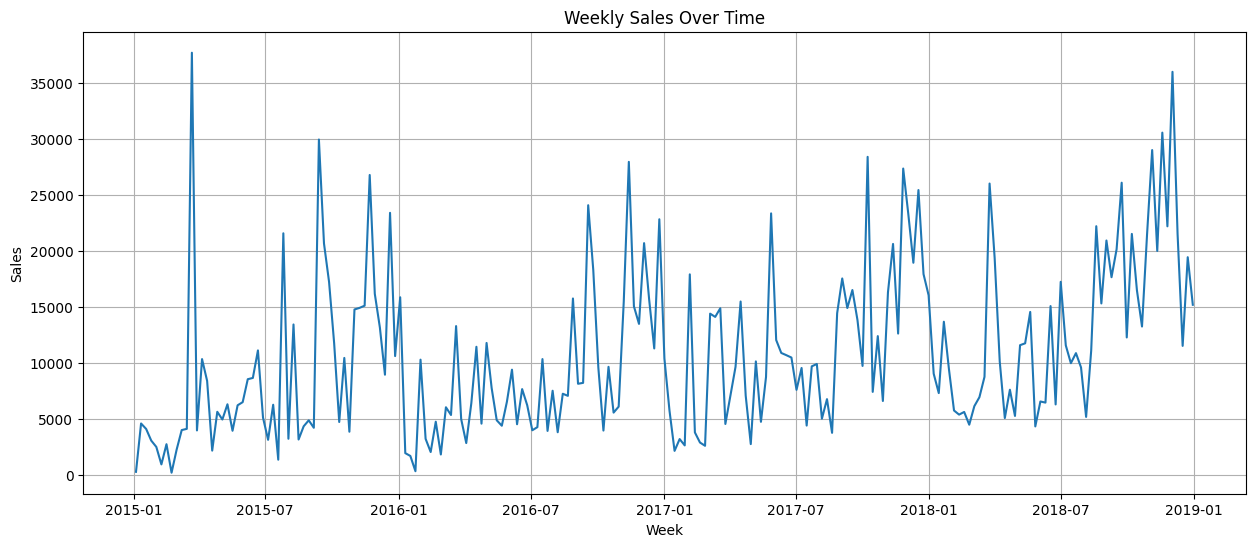

In [64]:
# Plot the weekly sales time series.
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    linewidth=1.5
)

plt.title("Weekly Sales Over Time")

plt.xlabel("Week")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

In [65]:
# Train the Isolation Forest model to identify anomalous sales weeks.
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation"] = iso.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Isolation"] = (
    weekly_sales["Isolation"] == -1
)

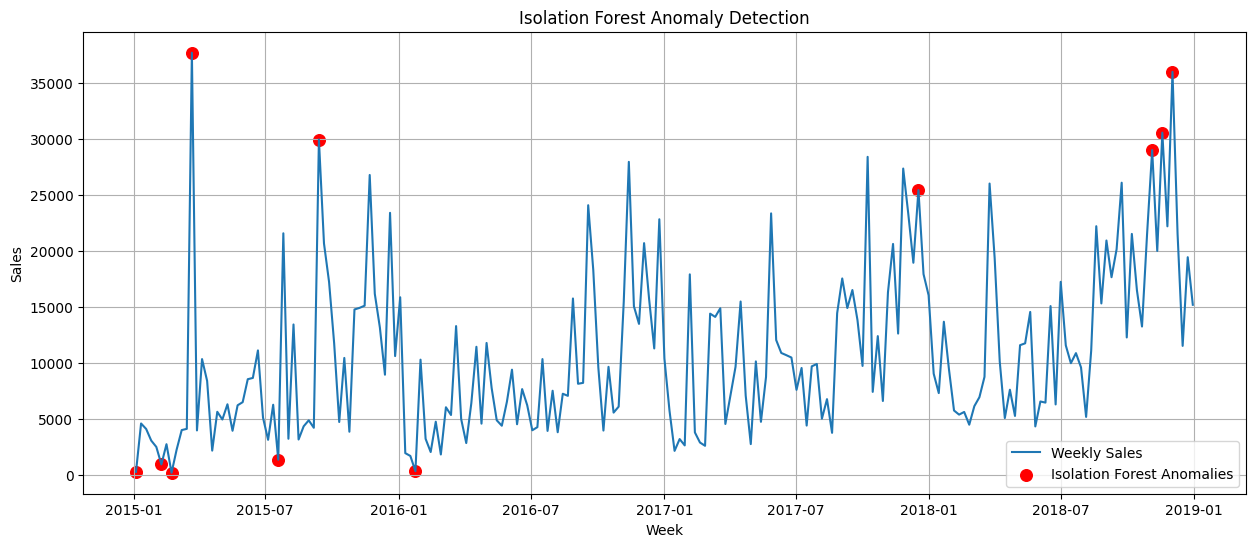

In [66]:
# Plot weekly sales and highlight anomalies detected by Isolation Forest.
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

anomalies = weekly_sales[
    weekly_sales["Isolation"]
]

plt.scatter(
    anomalies.index,
    anomalies["Sales"],
    color="red",
    s=70,
    label="Isolation Forest Anomalies"
)

plt.title("Isolation Forest Anomaly Detection")

plt.xlabel("Week")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [67]:
# Display all anomalies detected using Isolation Forest.
weekly_sales[
    weekly_sales["Isolation"]
]

,Sales,Isolation
Order Date,,
2015-01-04,304.508,True
2015-02-08,968.534,True
2015-02-22,224.912,True
2015-03-22,37703.665,True
2015-07-19,1387.686,True
2015-09-13,29959.137,True
2016-01-24,358.522,True
2017-12-17,25449.800,True
2018-11-04,29017.467,True


In [68]:
# Compute rolling mean, rolling standard deviation, and rolling Z-scores.
window = 8

weekly_sales["Rolling Mean"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .mean()
)

weekly_sales["Rolling Std"] = (
    weekly_sales["Sales"]
    .rolling(window)
    .std()
)

weekly_sales["Z-Score"] = (
    (weekly_sales["Sales"] -
     weekly_sales["Rolling Mean"])
    /
    weekly_sales["Rolling Std"]
)

In [69]:
# Flag weeks with Z-scores greater than two standard deviations.
weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z-Score"].abs() > 2
)

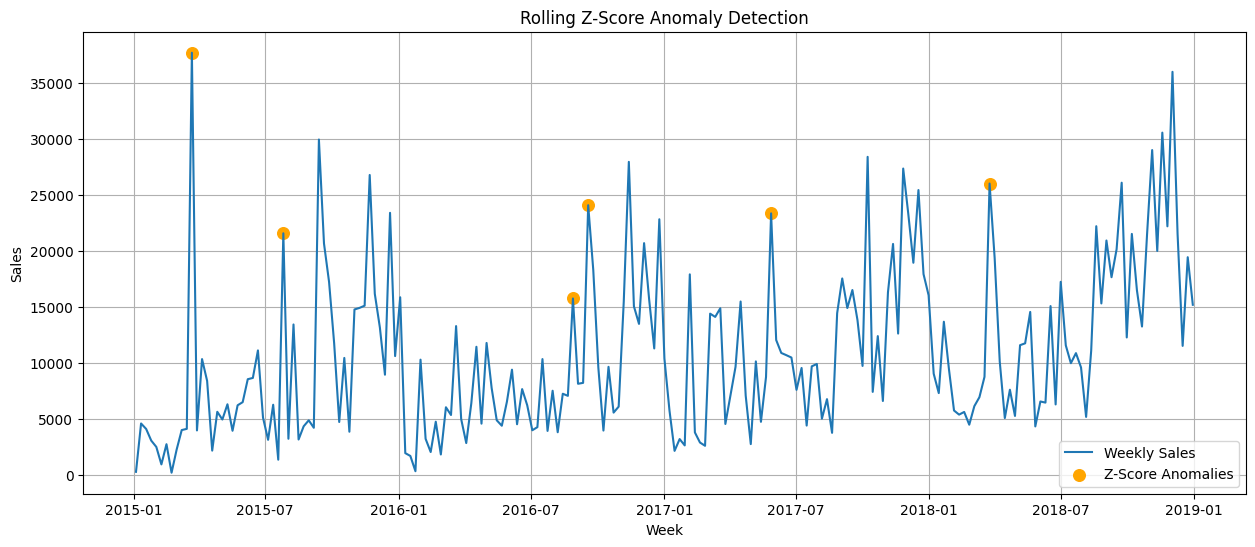

In [70]:
# Plot weekly sales and highlight anomalies detected using the rolling Z-score method.
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["Sales"],
    label="Weekly Sales"
)

z_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

plt.scatter(
    z_anomalies.index,
    z_anomalies["Sales"],
    color="orange",
    s=70,
    label="Z-Score Anomalies"
)

plt.title("Rolling Z-Score Anomaly Detection")

plt.xlabel("Week")
plt.ylabel("Sales")

plt.legend()
plt.grid(True)

plt.show()

In [71]:
# Display all anomalies detected using the rolling Z-score method.
weekly_sales[
    weekly_sales["Z_Anomaly"]
]

,Sales,Isolation,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly
Order Date,,,,,,
2015-03-22,37703.665,True,6832.006500,12546.138409,2.460650,True
2015-07-26,21590.080,False,8245.428325,6246.129535,2.136467,True
2016-08-28,15773.478,False,7515.302525,4020.682890,2.053924,True
2016-09-18,24095.960,False,10251.475400,6524.009519,2.122082,True
2017-05-28,23367.662,False,10265.959125,6524.022836,2.008225,True
2018-03-25,26029.904,False,8660.308925,7131.467537,2.435627,True


In [72]:
# Compare anomalies detected by Isolation Forest and the rolling Z-score method.
comparison = weekly_sales[
    ["Sales", "Isolation", "Z_Anomaly"]
]

comparison[
    (comparison["Isolation"])
    |
    (comparison["Z_Anomaly"])
]

,Sales,Isolation,Z_Anomaly
Order Date,,,
2015-01-04,304.508,True,False
2015-02-08,968.534,True,False
2015-02-22,224.912,True,False
2015-03-22,37703.665,True,True
2015-07-19,1387.686,True,False
2015-07-26,21590.080,False,True
2015-09-13,29959.137,True,False
2016-01-24,358.522,True,False
2016-08-28,15773.478,False,True


In [73]:
# Summarize the number of anomalies detected by each method.
print(
    "Isolation Forest:",
    weekly_sales["Isolation"].sum()
)

print(
    "Rolling Z-Score:",
    weekly_sales["Z_Anomaly"].sum()
)

Isolation Forest: 11
Rolling Z-Score: 6


In [74]:
# Identify anomalies detected by both methods.
common = weekly_sales[
    weekly_sales["Isolation"]
    &
    weekly_sales["Z_Anomaly"]
]

common

,Sales,Isolation,Rolling Mean,Rolling Std,Z-Score,Z_Anomaly
Order Date,,,,,,
2015-03-22,37703.665,True,6832.0065,12546.138409,2.46065,True


## Task 5 Summary

### Weekly Sales Anomaly Detection

Weekly sales data was analyzed using two complementary anomaly detection techniques:

1. **Isolation Forest**, an unsupervised machine learning algorithm that identifies observations that differ significantly from the overall data distribution.
2. **Rolling Z-Score Detection**, a statistical approach that identifies observations lying more than two standard deviations from the rolling mean.

Using both methods provides a comprehensive understanding of unusual sales behavior by combining machine learning and statistical perspectives.

---

## Isolation Forest Results

The Isolation Forest model detected **11 anomalous weeks** across the four-year period. These anomalies included both unusually high sales spikes and exceptionally low sales periods.

Examples of detected anomalies include:

- **2015-03-22** – Sales of **37,703.67**, representing the highest sales spike detected.
- **2015-09-13** – Sales of **29,959.14**, indicating another unusually high sales week.
- **2018-11-04** and **2018-11-18** – Large increases in weekly sales, likely associated with major holiday shopping periods.
- **2018-12-02** – Sales of **35,998.90**, suggesting continued year-end demand.
- Several unusually low sales weeks (such as **2015-01-04**, **2015-02-22**, and **2016-01-24**) were also identified, indicating periods of significantly lower activity compared to normal sales levels.

---

## Rolling Z-Score Results

Using an 8-week rolling window and a threshold of **±2 standard deviations**, the rolling Z-score method detected **6 anomalous weeks**.

These anomalies were primarily high-sales spikes that deviated substantially from the recent sales trend, including:

- **2015-03-22**
- **2015-07-26**
- **2016-08-28**
- **2016-09-18**
- **2017-05-28**
- **2018-03-25**

Unlike Isolation Forest, the rolling Z-score method focused mainly on sudden positive deviations from the local trend rather than unusually low sales periods.

---

## Comparison of Both Methods

| Method | Number of Anomalies |
|---------|--------------------:|
| Isolation Forest | **11** |
| Rolling Z-Score | **6** |

Only **one week (2015-03-22)** was identified as anomalous by **both methods**.

This indicates that although both techniques are designed to detect unusual observations, they evaluate anomalies differently:

- **Isolation Forest** considers the overall structure and distribution of the dataset, allowing it to detect both unusually high and unusually low sales weeks.
- **Rolling Z-Score** compares each week's sales against recent historical behavior, making it more sensitive to sharp local deviations while ignoring observations that remain statistically consistent with the recent trend.

The limited overlap between the two methods demonstrates that different anomaly detection techniques can identify different aspects of unusual behavior. Using both approaches together provides a more robust assessment than relying on a single method.

---

## Possible Business Explanations

Several plausible business events may explain the detected anomalies:

- **March 2015 (2015-03-22):** The largest sales spike observed in the dataset may correspond to a major promotional campaign, seasonal demand, or a large volume of corporate purchases.
- **November–December 2018:** High sales during early November and December are consistent with festive shopping periods such as **Black Friday**, **Cyber Monday**, and year-end holiday purchasing.
- **Very low sales weeks** detected by Isolation Forest may be associated with post-holiday slowdowns, operational disruptions, reduced customer demand, or temporary inventory shortages.

---

## Conclusion

Applying both Isolation Forest and Rolling Z-Score detection provided complementary insights into unusual sales behavior. Isolation Forest identified a broader range of anomalies, including both exceptionally high and exceptionally low sales weeks, whereas the rolling Z-score method focused on significant deviations from recent sales trends.

The fact that only one week was detected by both methods highlights that anomaly detection depends on the underlying methodology. Combining machine learning and statistical approaches therefore offers a more comprehensive understanding of sales irregularities and can help businesses investigate unusual events, validate promotional impacts, and improve future planning.

# Task 6 — Product Demand Segmentation using Clustering

In [75]:
# Aggregate monthly sales for each product sub-category.
monthly_subcategory = (
    df.groupby([
        "Sub-Category",
        pd.Grouper(key="Order Date", freq="ME")
    ])["Sales"]
    .sum()
    .reset_index()
)

monthly_subcategory.head()

,Sub-Category,Order Date,Sales
0,Accessories,2015-01-31,827.890
1,Accessories,2015-02-28,1120.990
2,Accessories,2015-03-31,957.734
3,Accessories,2015-04-30,2323.700
4,Accessories,2015-05-31,695.490


In [76]:
# Create demand-related features for each product sub-category.
feature_rows = []

for subcat in monthly_subcategory["Sub-Category"].unique():

    temp = monthly_subcategory[
        monthly_subcategory["Sub-Category"] == subcat
    ].copy()

    total_sales = temp["Sales"].sum()

    avg_order = (
        df[df["Sub-Category"] == subcat]["Sales"]
        .mean()
    )

    volatility = temp["Sales"].std()

    yearly_sales = (
        temp.groupby(
            temp["Order Date"].dt.year
        )["Sales"]
        .sum()
    )

    if len(yearly_sales) > 1:
        growth = yearly_sales.pct_change().mean() * 100
    else:
        growth = 0

    feature_rows.append([
        subcat,
        total_sales,
        growth,
        volatility,
        avg_order
    ])

cluster_df = pd.DataFrame(
    feature_rows,
    columns=[
        "Sub-Category",
        "Total Sales",
        "Growth Rate",
        "Volatility",
        "Average Order Value"
    ]
)

cluster_df

,Sub-Category,Total Sales,Growth Rate,Volatility,Average Order Value
0,Accessories,164186.7000,37.638071,2579.994809,217.178175
1,Appliances,104618.4030,39.927584,1821.621539,227.926804
2,Art,26705.4100,16.605553,330.488343,34.019631
3,Binders,200028.7850,21.873607,3848.223648,134.067550
4,Bookcases,113813.1987,23.806516,2220.405080,503.598224
5,Chairs,322822.7310,7.135790,4407.232960,531.833165
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212
7,Envelopes,16128.0460,-2.766643,228.218688,65.032444
8,Fasteners,3001.9600,15.703383,48.742229,14.027850
9,Furnishings,89212.0180,28.788938,1360.017867,95.823865


In [77]:
# Scale the clustering features before applying K-Means.
features = cluster_df.drop(
    "Sub-Category",
    axis=1
)

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [78]:
# Apply the Elbow Method to determine the optimal number of clusters.
wcss = []

for k in range(1,11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_features)

    wcss.append(km.inertia_)

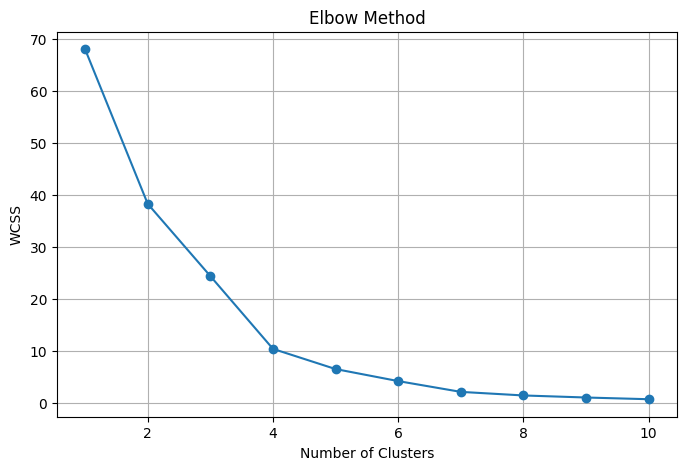

In [79]:
# Plot the Elbow Method results.
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.show()

Optinal number of clusters based on the above graph is **4** since that is where the steep decrease settles down into a steady decline.

**Interpretation:** After the elbow point, Increase in number of clusters does not lead to a significant improvement in the clustering as measured by the decreasing decline in wcss score

In [80]:
# Train the final K-Means model using the selected number of clusters.
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_df["Cluster"] = kmeans.fit_predict(
    scaled_features
)

cluster_df

,Sub-Category,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster
0,Accessories,164186.7000,37.638071,2579.994809,217.178175,2
1,Appliances,104618.4030,39.927584,1821.621539,227.926804,1
2,Art,26705.4100,16.605553,330.488343,34.019631,1
3,Binders,200028.7850,21.873607,3848.223648,134.067550,2
4,Bookcases,113813.1987,23.806516,2220.405080,503.598224,1
5,Chairs,322822.7310,7.135790,4407.232960,531.833165,2
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212,0
7,Envelopes,16128.0460,-2.766643,228.218688,65.032444,1
8,Fasteners,3001.9600,15.703383,48.742229,14.027850,1
9,Furnishings,89212.0180,28.788938,1360.017867,95.823865,1


In [81]:
# Reduce the feature space to two principal components.
pca = PCA(n_components=2)

pca_features = pca.fit_transform(
    scaled_features
)

In [82]:
# Create a DataFrame containing the PCA coordinates.
pca_df = pd.DataFrame({
    "PC1": pca_features[:,0],
    "PC2": pca_features[:,1],
    "Cluster": cluster_df["Cluster"],
    "Sub-Category": cluster_df["Sub-Category"]
})

pca_df.head()

,PC1,PC2,Cluster,Sub-Category
0,0.032855,-0.128039,2,Accessories
1,-0.562213,0.137443,1,Appliances
2,-1.728503,-0.152657,1,Art
3,0.617483,-0.594676,2,Binders
4,-0.119791,-0.064887,1,Bookcases


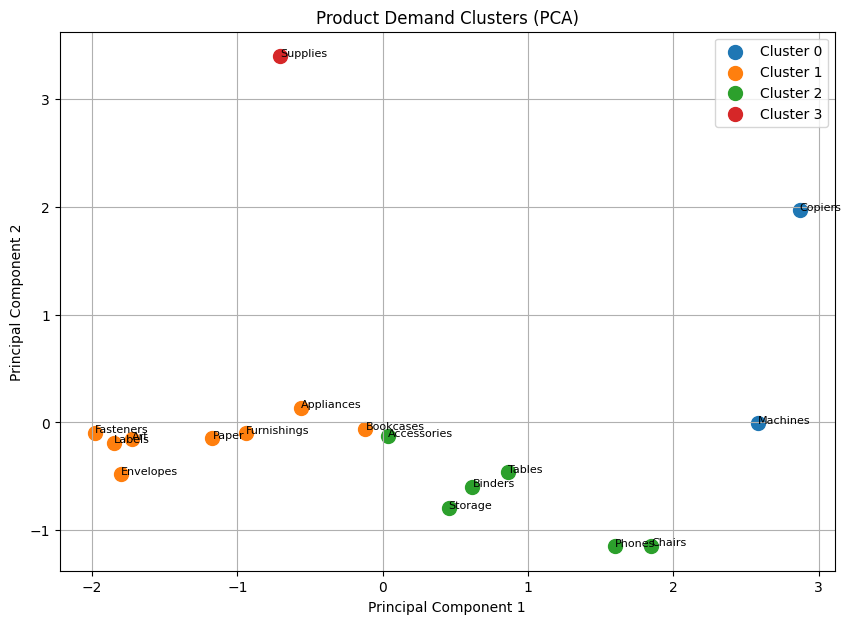

In [83]:
# Visualize the product demand clusters using PCA.
plt.figure(figsize=(10,7))

for cluster in sorted(pca_df["Cluster"].unique()):

    subset = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=100,
        label=f"Cluster {cluster}"
    )

    for _, row in subset.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=8
        )

plt.title("Product Demand Clusters (PCA)")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()

In [84]:
# Assign meaningful business labels to each demand cluster
# And display sub categories assigned to each cluster.
cluster_labels = {
    0: "Premium High-Value Products",
    1: "Low Volume, Stable Demand",
    2: "High Volume, Stable Demand",
    3: "Growing Demand"
}

cluster_df["Demand Segment"] = cluster_df["Cluster"].map(cluster_labels)

cluster_df.sort_values("Cluster")

,Sub-Category,Total Sales,Growth Rate,Volatility,Average Order Value,Cluster,Demand Segment
6,Copiers,146248.0940,84.671819,5500.774391,2215.880212,0,Premium High-Value Products
11,Machines,189238.6310,8.006001,5603.554747,1645.553313,0,Premium High-Value Products
4,Bookcases,113813.1987,23.806516,2220.405080,503.598224,1,"Low Volume, Stable Demand"
1,Appliances,104618.4030,39.927584,1821.621539,227.926804,1,"Low Volume, Stable Demand"
7,Envelopes,16128.0460,-2.766643,228.218688,65.032444,1,"Low Volume, Stable Demand"
9,Furnishings,89212.0180,28.788938,1360.017867,95.823865,1,"Low Volume, Stable Demand"
8,Fasteners,3001.9600,15.703383,48.742229,14.027850,1,"Low Volume, Stable Demand"
2,Art,26705.4100,16.605553,330.488343,34.019631,1,"Low Volume, Stable Demand"
12,Paper,76828.3040,25.413074,1024.824982,57.420257,1,"Low Volume, Stable Demand"
10,Labels,12347.7260,12.192651,223.471218,34.587468,1,"Low Volume, Stable Demand"


In [85]:
# Display the product sub-categories grouped by their demand segment.
cluster_summary = cluster_df[[
    "Sub-Category",
    "Demand Segment",
    "Total Sales",
    "Growth Rate",
    "Volatility",
    "Average Order Value"
]].sort_values("Demand Segment")

cluster_summary

,Sub-Category,Demand Segment,Total Sales,Growth Rate,Volatility,Average Order Value
15,Supplies,Growing Demand,46420.3080,192.844843,2025.094139,252.284283
0,Accessories,"High Volume, Stable Demand",164186.7000,37.638071,2579.994809,217.178175
14,Storage,"High Volume, Stable Demand",219343.3920,13.179873,2822.084310,263.633885
13,Phones,"High Volume, Stable Demand",327782.4480,12.340878,4052.718221,374.180877
5,Chairs,"High Volume, Stable Demand",322822.7310,7.135790,4407.232960,531.833165
16,Tables,"High Volume, Stable Demand",202810.6280,16.410685,3224.082504,645.893720
3,Binders,"High Volume, Stable Demand",200028.7850,21.873607,3848.223648,134.067550
7,Envelopes,"Low Volume, Stable Demand",16128.0460,-2.766643,228.218688,65.032444
9,Furnishings,"Low Volume, Stable Demand",89212.0180,28.788938,1360.017867,95.823865
10,Labels,"Low Volume, Stable Demand",12347.7260,12.192651,223.471218,34.587468


## Task 6 Summary

### Product Demand Segmentation using K-Means Clustering

Product demand segmentation was performed at the **sub-category** level using the K-Means clustering algorithm. Four demand-related features were engineered for each product sub-category:

- Total Sales Volume
- Year-over-Year Sales Growth Rate
- Sales Volatility (Standard Deviation of Monthly Sales)
- Average Order Value

Since these features have different scales, they were standardized before clustering. The Elbow Method was used to determine the appropriate number of clusters, after which the final K-Means model was trained. Principal Component Analysis (PCA) was applied to reduce the feature space to two dimensions for visualization.

---

## Cluster Interpretation

### Cluster 0 — Premium High-Value Products

**Sub-Categories:**
- Copiers
- Machines

**Characteristics:**

- Very high average order values
- High total sales
- High monthly sales volatility
- Premium-priced products with relatively fewer but larger transactions

**Recommended Stocking Strategy:**

Maintain moderate inventory levels while closely monitoring demand forecasts. Since these products represent high-value purchases, inventory should be carefully managed to avoid excessive holding costs while ensuring availability for large customer orders.

---

### Cluster 1 — Low Volume, Stable Demand

**Sub-Categories:**

- Appliances
- Bookcases
- Envelopes
- Furnishings
- Fasteners
- Art
- Paper
- Labels

**Characteristics:**

- Lower overall sales volume
- Relatively stable monthly demand
- Moderate to low average order values
- Consistent purchasing behavior

**Recommended Stocking Strategy:**

Maintain steady inventory with periodic replenishment. These products exhibit predictable demand patterns, making them suitable for routine stock management and minimizing excess inventory.

---

### Cluster 2 — High Volume, Stable Demand

**Sub-Categories:**

- Accessories
- Binders
- Chairs
- Phones
- Storage
- Tables

**Characteristics:**

- Highest total sales volume
- Strong and consistent customer demand
- Moderate sales volatility
- Core revenue-generating product categories

**Recommended Stocking Strategy:**

Prioritize inventory availability and maintain higher stock levels. These products contribute significantly to overall revenue, making stock-outs costly. Frequent replenishment and continuous inventory monitoring are recommended.

---

### Cluster 3 — Growing Demand

**Sub-Category:**

- Supplies

**Characteristics:**

- Exceptionally high year-over-year growth rate
- Moderate total sales volume
- Strong growth potential
- Demand increasing rapidly compared to other sub-categories

**Recommended Stocking Strategy:**

Gradually increase inventory levels while continuously monitoring demand trends. As demand continues to grow, inventory policies should be adjusted to accommodate future sales without creating unnecessary overstock.

---

## Conclusion

The K-Means clustering model successfully segmented product sub-categories into four meaningful demand groups based on historical sales performance, growth, volatility, and order value. The segmentation highlights that different products require different inventory management strategies.

High-volume products should receive priority in inventory planning, premium products require careful stock optimization due to their high value, stable-demand products benefit from regular replenishment cycles, and rapidly growing products should be monitored closely to ensure inventory keeps pace with increasing demand.

Overall, the clustering analysis provides valuable business insights that can support demand forecasting, inventory optimization, and strategic product planning.

# Task 7 — Streamlit Dashboard

An interactive dashboard was developed using Streamlit to present the results of this project.

The dashboard includes:

- 📊 Sales Overview Dashboard
- 📈 Forecast Explorer (XGBoost)
- ⚠️ Anomaly Detection Report
- 📦 Product Demand Segmentation

The application was deployed using Streamlit Community Cloud.

**Live Dashboard:** *https://vaishnavi-xylofi-w34.streamlit.app/*

# Exporting Key Details for Dashboard


**Note:** Please run the below cell and the extract the csv folders from dashboard_data.zip file into the dashboard_data folder in the root dir of SalesForecastDashboard.

In [86]:
# EXPORT PRECOMPUTED RESULTS FOR THE STREAMLIT DASHBOARD

OUT_DIR = "dashboard_data"
os.makedirs(OUT_DIR, exist_ok=True)

# ---- 1. Task 3 — Model comparison table (SARIMA / Prophet / XGBoost) ----
comparison_df.to_csv(f"{OUT_DIR}/model_comparison.csv", index=False)

# ---- 2. Task 4 — Category & region 3-month forecasts ----
# forecast_table: index = forecast month, columns = segment name
segment_forecasts = (
    forecast_table
    .reset_index()
    .rename(columns={"index": "Date"})
    .melt(id_vars="Date", var_name="Segment", value_name="Forecast")
    .sort_values(["Segment", "Date"])
)
segment_forecasts.to_csv(f"{OUT_DIR}/segment_forecasts.csv", index=False)

# ---- 3. Task 5 — Weekly sales + Isolation Forest anomaly flags ----
weekly_anomalies = weekly_sales.reset_index().rename(columns={"Order Date": "Week"})
weekly_anomalies.to_csv(f"{OUT_DIR}/weekly_anomalies.csv", index=False)

# ---- 4. Task 6 — Cluster features + demand segment labels + PCA coords ----
demand_clusters = cluster_df.merge(
    pca_df[["Sub-Category", "PC1", "PC2"]],
    on="Sub-Category",
    how="left",
)
demand_clusters.to_csv(f"{OUT_DIR}/demand_clusters.csv", index=False)

print("Exported to", OUT_DIR, ":")
for f in os.listdir(OUT_DIR):
    print(" -", f)

# ---- Optional: zip + download if running in Google Colab ----
try:
    from google.colab import files
    import shutil
    shutil.make_archive(OUT_DIR, "zip", OUT_DIR)
    files.download(f"{OUT_DIR}.zip")
except ImportError:
    pass  # not running in Colab — the dashboard_data/ folder is already on disk

Exported to dashboard_data :
 - segment_forecasts.csv
 - weekly_anomalies.csv
 - demand_clusters.csv
 - model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>